# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [2]:
train_fname = 'data/tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)

In [3]:
# Перші 5 рядків
print("\n=== Перші 5 рядків ===")
display(raw_df.head())

# Інформація про структуру
print("\n=== Інформація про дані ===")
print(raw_df.info())

# Кількість пропусків
print("\n=== Пропущені значення ===")
print(raw_df.isna().sum())

# Видаляємо рядки з пропусками
df_clean = raw_df.dropna()

print("\n=== Розмір після видалення пропусків ===")
print(df_clean.shape)


=== Перші 5 рядків ===


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative



=== Інформація про дані ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
None

=== Пропущені значення ===
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

=== Розмір після видалення пропусків ===
(27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



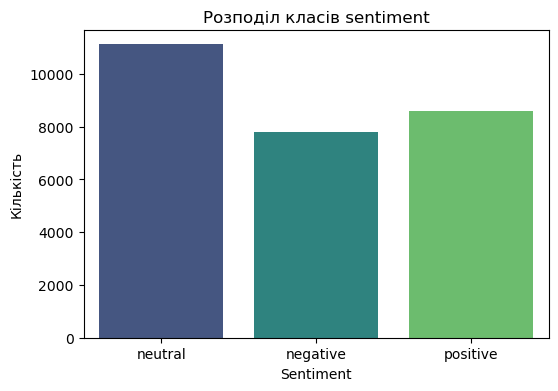

In [4]:
df_eda = df_clean.copy()

# Розподіл класів
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_eda,
    x='sentiment',
    hue='sentiment',
    palette='viridis',
    legend=False
)
plt.title("Розподіл класів sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Кількість")
plt.show();

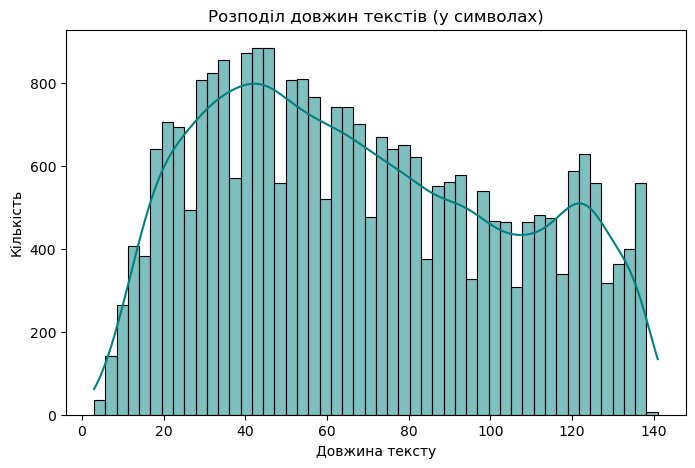

In [5]:
# Довжина текстів у символах
df_eda['text_length'] = df_eda['text'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df_eda['text_length'], bins=50, kde=True, color='teal')
plt.title("Розподіл довжин текстів (у символах)")
plt.xlabel("Довжина тексту")
plt.ylabel("Кількість")
plt.show();

In [6]:
# Базова статистика довжин
df_eda['text_length'].describe()

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_length, dtype: float64

Найбільше текстів довжиною 30-50 символів.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
import re

# Завантаження необхідних ресурсів
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mariy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mariy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

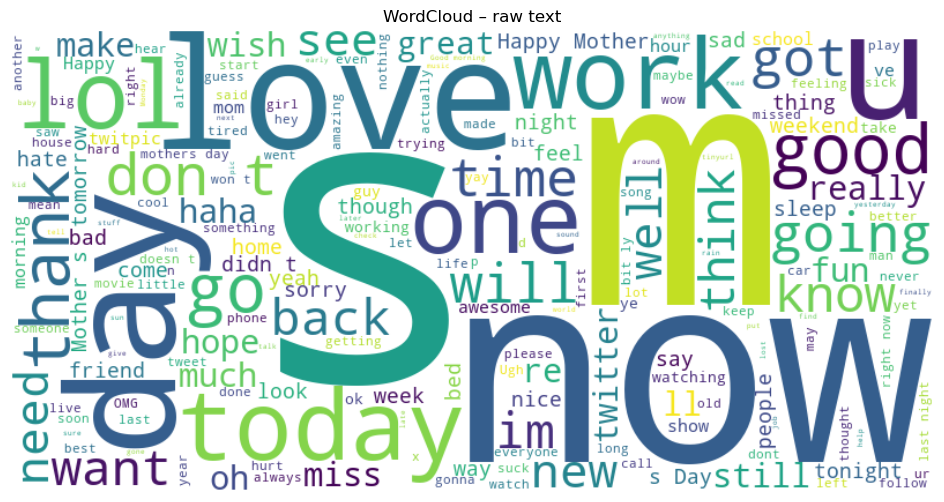

In [9]:
from wordcloud import WordCloud

text_raw = " ".join(df_clean['text'].astype(str).tolist())

wc_raw = WordCloud(width=800, height=400, background_color='white').generate(text_raw)

plt.figure(figsize=(12, 6))
plt.imshow(wc_raw, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud – raw text")
plt.show()

І додала цю візуалізацію з WordCloud для того, щоб зрозуміти чи слова, які найчастіше зустрічаються, несуть в собі контекст і чи мають якесь позитивне чи негативне забарвлення. З зображення видно, більшість частих слів мають позитивне чи нейтральне забарвлення, часто зустрічаються скорочення як "u" чи "s".

In [10]:
# Contractions map
contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "can not",
    "couldn't": "could not",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "you're": "you are",
    "we're": "we are",
    "they're": "they are",
    "it's": "it is",
    "that's": "that is"
}

def expand_contractions(text):
    for c, full in contractions.items():
        text = text.replace(c, full)
    return text


def preprocess_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Replace censored profanity **** → badword
    text = re.sub(r"\*{2,}", " badword ", text)

    # 3. Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 4. Expand contractions
    text = expand_contractions(text)

    # 5. Normalize repeated letters (soooo → soo)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # 6. Remove unwanted characters (keep letters and apostrophes)
    text = re.sub(r"[^a-zA-Z']", " ", text)

    # 7. Tokenize
    tokens = word_tokenize(text)

    # 8. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 9. Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens

In [11]:
# Визначаємо розмір словника
max_features = 5000

vectorizer = CountVectorizer(
    tokenizer=preprocess_text,
    token_pattern=None,
    max_features=max_features
)

X_bow = vectorizer.fit_transform(df_clean['text'])

In [12]:
all_tokens = []
for t in df_clean['text']:
    all_tokens.extend(preprocess_text(t))

len(set(all_tokens))

17990

In [13]:
print("Розмір матриці:", X_bow.shape)
print("Приклад фіч:", vectorizer.get_feature_names_out()[20:40])

Розмір матриці: (27480, 5000)
Приклад фіч: ['ac' 'academ' 'academi' 'accept' 'access' 'accid' 'accident' 'accomplish'
 'accord' 'account' 'acct' 'ace' 'ach' 'achiev' 'acid' 'ack' 'across'
 'act' 'action' 'activ']


Я залишила розмір словника, який з обраним методом препроцесингу надавав найкращі результати на класифікації.

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [14]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow,
    df_clean['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_clean['sentiment']
)

X_train_bow.shape, X_test_bow.shape

((21984, 5000), (5496, 5000))

In [15]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(X_train_bow, y_train)

# --- TRAIN PREDICTIONS ---
y_pred_train = logreg.predict(X_train_bow)
print("\n=== TRAIN RESULTS ===")
print("F1-macro:", round(f1_score(y_train, y_pred_train, average='macro'), 3))
print(classification_report(y_train, y_pred_train))

# --- TEST PREDICTIONS ---
y_pred_test = logreg.predict(X_test_bow)
print("=== TEST RESULTS ===")
print("F1-macro:", round(f1_score(y_test, y_pred_test, average='macro'), 3))
print(classification_report(y_test, y_pred_test))


=== TRAIN RESULTS ===
F1-macro: 0.826
              precision    recall  f1-score   support

    negative       0.81      0.83      0.82      6225
     neutral       0.82      0.80      0.81      8894
    positive       0.84      0.86      0.85      6865

    accuracy                           0.82     21984
   macro avg       0.82      0.83      0.83     21984
weighted avg       0.82      0.82      0.82     21984

=== TEST RESULTS ===
F1-macro: 0.694
              precision    recall  f1-score   support

    negative       0.67      0.69      0.68      1556
     neutral       0.66      0.65      0.66      2223
    positive       0.75      0.74      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496



In [16]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist'
)

xgb.fit(X_train_bow, y_train_enc)

# --- TRAIN PREDICTIONS ---
y_pred_train_xgb = xgb.predict(X_train_bow)

print("=== TRAIN RESULTS (XGBoost) ===")
print("F1-macro:", round(f1_score(y_train_enc, y_pred_train_xgb, average='macro'), 3))
print(classification_report(y_train_enc, y_pred_train_xgb, target_names=le.classes_))

# --- TEST PREDICTIONS ---
y_pred_test_xgb = xgb.predict(X_test_bow)

print("\n=== TEST RESULTS (XGBoost) ===")
print("F1-macro:", round(f1_score(y_test_enc, y_pred_test_xgb, average='macro'), 3))
print(classification_report(y_test_enc, y_pred_test_xgb, target_names=le.classes_))

=== TRAIN RESULTS (XGBoost) ===
F1-macro: 0.746
              precision    recall  f1-score   support

    negative       0.81      0.62      0.71      6225
     neutral       0.68      0.83      0.75      8894
    positive       0.81      0.75      0.78      6865

    accuracy                           0.75     21984
   macro avg       0.77      0.74      0.75     21984
weighted avg       0.76      0.75      0.75     21984


=== TEST RESULTS (XGBoost) ===
F1-macro: 0.701
              precision    recall  f1-score   support

    negative       0.76      0.59      0.66      1556
     neutral       0.64      0.78      0.70      2223
    positive       0.78      0.71      0.74      1717

    accuracy                           0.70      5496
   macro avg       0.72      0.69      0.70      5496
weighted avg       0.71      0.70      0.70      5496



**Висновок**

Фінальна якість класифікації є стабільною та загалом хорошою для класичних ML‑методів, які працюють з короткими, шумними текстами.
Моделі показують F1‑macro ≈ 0.69 - 0.71, що є хорошим результатом для 3‑класової класифікації емоційних повідомлень.
Моделі добре розпізнають positive та neutral, але трохи гірше - negative.
Різниця між train і test (приблизно 0.80 - 0.70) свідчить про легке, але прийнятне переобучення, без критичних проблем.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [17]:
coefs = logreg.coef_
feature_names = vectorizer.get_feature_names_out()
classes = logreg.classes_

for idx, cls in enumerate(classes):
    print(f"\n=== Топ позитивних слів для '{cls}' ===")
    top_pos = np.argsort(coefs[idx])[-20:]
    print([feature_names[i] for i in top_pos])

    print(f"\n=== Топ негативних слів для '{cls}' ===")
    top_neg = np.argsort(coefs[idx])[:20]
    print([feature_names[i] for i in top_neg])


=== Топ позитивних слів для 'negative' ===
['horribl', 'wtf', 'hurt', 'terribl', 'headach', 'jealous', 'shame', 'exhaust', 'disappoint', 'wors', 'unfortun', 'miss', 'stupid', 'worst', 'fail', 'hate', 'sorri', 'bore', 'suck', 'sad']

=== Топ негативних слів для 'negative' ===
['glad', 'awesom', 'love', 'beauti', 'thank', 'cute', 'welcom', 'amaz', 'enjoy', 'great', 'nice', 'congrat', 'fine', 'hope', 'yum', 'bless', 'star', 'yummi', 'excit', 'sexi']

=== Топ позитивних слів для 'neutral' ===
['england', 'physic', 'there', 'attract', 'pfft', 'bash', 'jst', 'twhirl', 'how', 'guitar', 'starwarsday', 'opinion', 'eu', 'moro', 'humm', 'colorado', 'otherwis', 'sp', 'chan', 'indoor']

=== Топ негативних слів для 'neutral' ===
['forum', 'thrill', 'congratul', 'wtf', 'truli', 'incred', 'product', 'impati', 'delici', 'proud', 'dam', 'favourit', 'migrain', 'stole', 'import', 'hmph', 'thnx', 'appropri', 'accomplish', 'blast']

=== Топ позитивних слів для 'positive' ===
['happi', 'interest', 'gorgeous

In [18]:
def plot_top_words(coefs, feature_names, class_index, class_name, top_n=20):
    coef = coefs[class_index]
    top_idx = np.argsort(coef)[-top_n:]
    words = feature_names[top_idx]
    values = coef[top_idx]

    plt.figure(figsize=(8,6))
    plt.barh(words, values, color='teal')
    plt.title(f"Top {top_n} слів для класу '{class_name}'")
    plt.show()

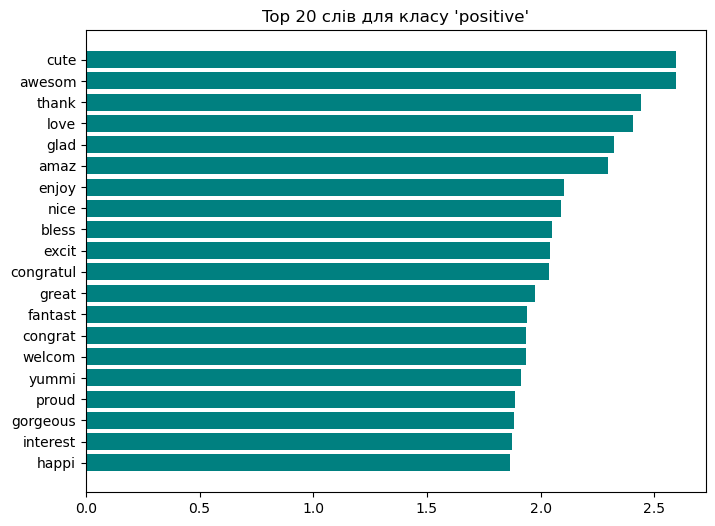

In [19]:
plot_top_words(coefs, feature_names, 2, "positive")

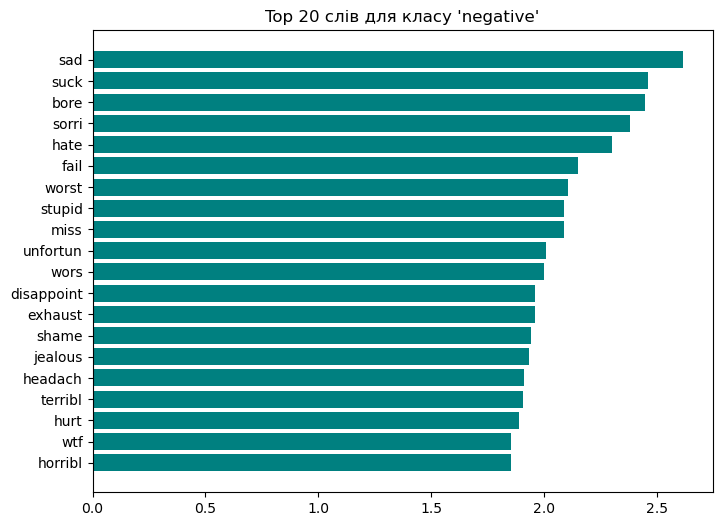

In [20]:
plot_top_words(coefs, feature_names, 0, "negative")

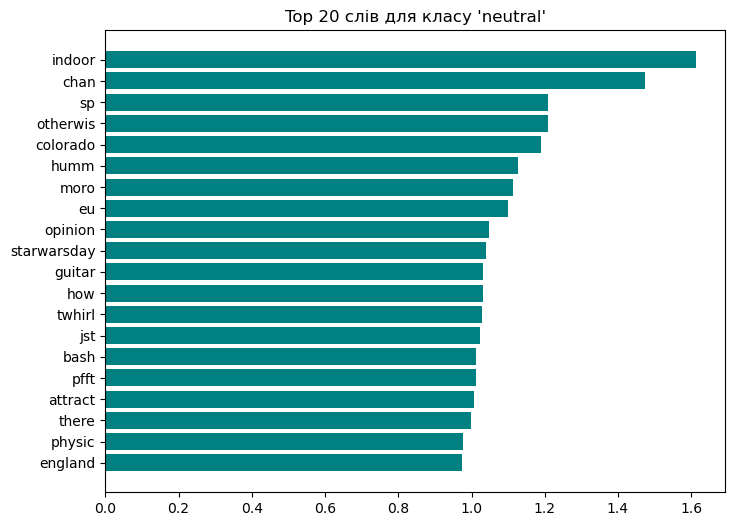

In [21]:
plot_top_words(coefs, feature_names, 1, "neutral")

In [22]:
# Важливість ознак
importance = xgb.feature_importances_

feature_names = vectorizer.get_feature_names_out()

# Створюємо таблицю
df_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

# Сортуємо за важливістю
df_imp_sorted = df_imp.sort_values(by='importance', ascending=False)

df_imp_sorted.head(20)

,feature,importance
4304,thank,0.011251
1915,happi,0.009183
1931,hate,0.007232
3735,sad,0.006162
2663,love,0.006048
137,amaz,0.006028
2123,hurt,0.005717
3002,nice,0.005561
927,cool,0.005298
300,awesom,0.005274


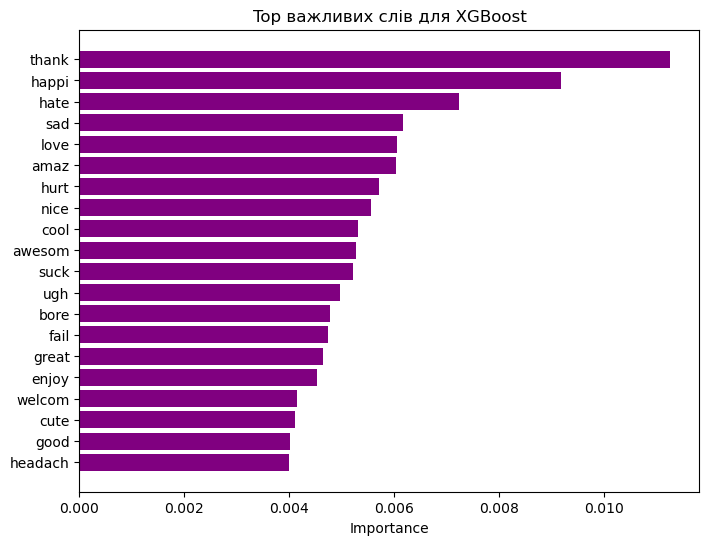

In [23]:
top_n = 20
top_features = df_imp_sorted.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top_features['feature'], top_features['importance'], color='purple')
plt.gca().invert_yaxis()
plt.title("Top важливих слів для XGBoost")
plt.xlabel("Importance")
plt.show()

Моделі (Logistic Regression і XGBoost) виділяють саме ті слова, які інтуїтивно та лінгвістично відповідають позитивному, негативному та нейтральному сентименту.
Найважливіші ознаки повністю логічні:
- негатив - sad, hate, hurt, disappoint, worst
- позитив - love, great, happi, amaz, congrat
- нейтральний - тематичні або неемоційні слова

Це свідчить про:
- коректну роботу preprocessing
- адекватне навчання моделей
- відсутність “дивних” або нелогічних ознак
- хорошу інтерпретованість результатів

Тобто модель поводиться логічно, стабільно і правильно вловлює семантику текстів.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [24]:
df_clean = df_clean.reset_index(drop=True)

In [25]:
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    df_clean.index,
    df_clean['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_clean['sentiment']
)

In [26]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=preprocess_text,
    token_pattern=None,
    ngram_range=(1, 2),
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(df_clean['text'])

In [27]:
X_train_tfidf = X_tfidf[X_train_idx]
X_test_tfidf = X_tfidf[X_test_idx]

In [28]:
logreg_tfidf = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg_tfidf.fit(X_train_tfidf, y_train)

# --- TRAIN ---
y_pred_train_tfidf = logreg_tfidf.predict(X_train_tfidf)
print("\n=== TRAIN RESULTS (TF-IDF Logistic Regression) ===")
print("F1-macro:", round(f1_score(y_train, y_pred_train_tfidf, average='macro'), 3))
print(classification_report(y_train, y_pred_train_tfidf))

# --- TEST ---
y_pred_test_tfidf = logreg_tfidf.predict(X_test_tfidf)
print("=== TEST RESULTS (TF-IDF Logistic Regression) ===")
print("F1-macro:", round(f1_score(y_test, y_pred_test_tfidf, average='macro'), 3))
print(classification_report(y_test, y_pred_test_tfidf))


=== TRAIN RESULTS (TF-IDF Logistic Regression) ===
F1-macro: 0.793
              precision    recall  f1-score   support

    negative       0.77      0.79      0.78      6225
     neutral       0.78      0.77      0.77      8894
    positive       0.82      0.83      0.82      6865

    accuracy                           0.79     21984
   macro avg       0.79      0.79      0.79     21984
weighted avg       0.79      0.79      0.79     21984

=== TEST RESULTS (TF-IDF Logistic Regression) ===
F1-macro: 0.698
              precision    recall  f1-score   support

    negative       0.68      0.70      0.69      1556
     neutral       0.66      0.67      0.66      2223
    positive       0.75      0.73      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.70      0.70      5496
weighted avg       0.70      0.69      0.69      5496



In [29]:
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_tfidf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist'
)

xgb_tfidf.fit(X_train_tfidf, y_train_enc)

# --- TRAIN ---
y_pred_train_xgb_tfidf = xgb_tfidf.predict(X_train_tfidf)

print("=== TRAIN RESULTS (TF-IDF XGBoost) ===")
print("F1-macro:", round(f1_score(y_train_enc, y_pred_train_xgb_tfidf, average='macro'), 3))
print(classification_report(y_train_enc, y_pred_train_xgb_tfidf, target_names=le.classes_))

# --- TEST ---
y_pred_test_xgb_tfidf = xgb_tfidf.predict(X_test_tfidf)

print("\n=== TEST RESULTS (TF-IDF XGBoost) ===")
print("F1-macro:", round(f1_score(y_test_enc, y_pred_test_xgb_tfidf, average='macro'), 3))
print(classification_report(y_test_enc, y_pred_test_xgb_tfidf, target_names=le.classes_))

=== TRAIN RESULTS (TF-IDF XGBoost) ===
F1-macro: 0.763
              precision    recall  f1-score   support

    negative       0.84      0.63      0.72      6225
     neutral       0.69      0.86      0.77      8894
    positive       0.84      0.77      0.80      6865

    accuracy                           0.77     21984
   macro avg       0.79      0.75      0.76     21984
weighted avg       0.78      0.77      0.76     21984


=== TEST RESULTS (TF-IDF XGBoost) ===
F1-macro: 0.693
              precision    recall  f1-score   support

    negative       0.76      0.57      0.65      1556
     neutral       0.62      0.78      0.70      2223
    positive       0.77      0.69      0.73      1717

    accuracy                           0.70      5496
   macro avg       0.72      0.68      0.69      5496
weighted avg       0.71      0.70      0.69      5496



In [30]:
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
coefs_tfidf = logreg_tfidf.coef_
classes = logreg_tfidf.classes_

for idx, cls in enumerate(classes):
    print(f"\n=== Топ позитивних слів для '{cls}' (TF-IDF) ===")
    top_pos = np.argsort(coefs_tfidf[idx])[-20:]
    print([feature_names_tfidf[i] for i in top_pos])

    print(f"\n=== Топ негативних слів для '{cls}' (TF-IDF) ===")
    top_neg = np.argsort(coefs_tfidf[idx])[:20]
    print([feature_names_tfidf[i] for i in top_neg])


=== Топ позитивних слів для 'negative' (TF-IDF) ===
['wtf', 'badword', 'disappoint', 'ugh', 'unfortun', 'worst', 'headach', 'poor', 'bad', 'tire', 'stupid', 'hurt', 'sick', 'fail', 'bore', 'hate', 'suck', 'sorri', 'miss', 'sad']

=== Топ негативних слів для 'negative' (TF-IDF) ===
['love', 'thank', 'awesom', 'glad', 'hope', 'great', 'amaz', 'enjoy', 'nice', 'cute', 'best', 'welcom', 'beauti', 'yay', 'good', 'excit', 'haha', 'cool', 'lol', 'fun']

=== Топ позитивних слів для 'neutral' (TF-IDF) ===
['england', 'workin', 'grade', 'goin', 'realis', 'wolverin', 'avail', 'click', 'sp', 'better soon', 'starwarsday', 'differ', 'sent', 'except', 'moro', 'how', 'hope nice', 'guitar', 'indoor', 'there']

=== Топ негативних слів для 'neutral' (TF-IDF) ===
['good', 'happi', 'thank', 'nice', 'excit', 'fail', 'hurt', 'fun', 'stupid', 'great', 'funni', 'love', 'worri', 'feel', 'perfect', 'amaz', 'wish', 'wtf', 'hate', 'badword']

=== Топ позитивних слів для 'positive' (TF-IDF) ===
['welcom', 'cool', 

In [31]:
importance_tfidf = xgb_tfidf.feature_importances_

df_imp_tfidf = pd.DataFrame({
    'feature': feature_names_tfidf,
    'importance': importance_tfidf
}).sort_values(by='importance', ascending=False)

df_imp_tfidf.head(20)

,feature,importance
1850,happi,0.008351
4208,thank,0.006922
2822,mother,0.006758
101,amaz,0.006169
3611,sad,0.005678
1873,hate,0.005504
2983,nice,0.005348
4544,ugh,0.005337
431,bore,0.005327
1755,great,0.005008


In [32]:
feature_names_bow = vectorizer.get_feature_names_out()
coefs_bow = logreg.coef_

def top_words_logreg(coefs, feature_names, class_index, top_n=20):
    idx = np.argsort(coefs[class_index])[-top_n:]
    return [feature_names[i] for i in idx]

feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
coefs_tfidf = logreg_tfidf.coef_

def top_words_xgb(model, feature_names, top_n=20):
    imp = model.feature_importances_
    idx = np.argsort(imp)[-top_n:]
    return [feature_names[i] for i in idx]

In [33]:
cls_index = list(logreg.classes_).index("positive")

df_compare = pd.DataFrame({
    "LogReg BOW": top_words_logreg(coefs_bow, feature_names_bow, cls_index),
    "LogReg TF-IDF": top_words_logreg(coefs_tfidf, feature_names_tfidf, cls_index),
    "XGBoost BOW": top_words_xgb(xgb, feature_names_bow),
    "XGBoost TF-IDF": top_words_xgb(xgb_tfidf, feature_names_tfidf)
})

df_compare

,LogReg BOW,LogReg TF-IDF,XGBoost BOW,XGBoost TF-IDF
0,happi,welcom,headach,worst
1,interest,cool,good,sick
2,gorgeous,sweet,cute,good
3,proud,interest,welcom,excit
4,yummi,yay,enjoy,fail
5,welcom,best,great,enjoy
6,congrat,glad,fail,awesom
7,fantast,fun,bore,hurt
8,great,cute,ugh,suck
9,congratul,enjoy,suck,love


**Висновок**

Обидві моделі вловлюють однакову семантику.

Хоча якість класифікації майже однакова, TF‑IDF має важливі переваги:
1) Менше шуму - TF‑IDF зменшує вагу частих слів, які не несуть емоційного змісту.
2) Краща інтерпретованість - Важливі слова у TF‑IDF - більш “емоційні” (wtf, ugh, badword) та логічні.
3) Краща узагальнюваність - TF‑IDF менш схильний до переобучення, ніж BoW.
4) Краще виділяє фрази, які рідко зустрічаються, але несуть сильний сентимент

Для фінальної імплементації я б обрала TF‑IDF, оскільки він дає чистіші ознаки, краще відображає емоційні маркери та забезпечує більш стабільну інтерпретацію, навіть якщо F1‑macro залишається на тому ж рівні.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [34]:
pd.set_option('display.max_colwidth', None)

# Прогнози моделі логрег TF-IDF
y_pred = y_pred_test_tfidf

# Створюємо таблицю з помилками
errors = pd.DataFrame({
    "text": df_clean.loc[X_test_idx, "text"].values,
    "true": y_test.values,
    "pred": y_pred
})

errors_misclassified = errors[errors["true"] != errors["pred"]]
errors_misclassified.head(20)

,text,true,pred
7,Why must Jay Leno leave his own show,neutral,negative
8,Hoping that this will just heal on it`s own because anything I put on it just makes it worse. Owww,neutral,negative
14,Having a wonderful piece of cake for lunch - what else could I want???,positive,neutral
15,"Don`t worry, you`ll get your stamina back soon What kind of distances do you run usually?",positive,neutral
17,shack idol today(: can`t wait. it`s gonna be funnn poor cameron. he fell ON A BAR in speech today. i felt so bad for him,neutral,negative
18,"Awww, *hugs* I wish I could help.",negative,positive
19,2 hours after teleconference. but can`t go back to sleep. got some work to do. sigh sigh,negative,neutral
22,i don`t know the guys on radio disney have so much energy. i wouldn`t be able to do it <3,neutral,negative
24,**** Frat - that`s too bad... Should be a good show (at least I`m hoping so) esp. since it`s in BK...,neutral,positive
31,Im home where i am about 2 drink alone.,negative,neutral


In [35]:
errors_misclassified['true'].value_counts()

true
neutral     744
negative    474
positive    460
Name: count, dtype: int64

**Висновок**

TF‑IDF + Logistic Regression:
- добре працює на сильних емоційних словах
- погано працює на контексті, сарказмі, непрямих емоціях
- часто плутає м’який позитив і м’який негатив з нейтральним
- не розуміє фраз типу can’t wait, aww, hugs, poor guy

Можливі покращення:
1) Додати додаткові методи препроцесінгу - інтерпретація емоджі, спробувати лематизацію
2) Спробувати n‑grams (1,3)
3) Додати word embeddings (GloVe / fastText)
4) Перейти на трансформери (BERT)

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model